In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [17]:
file_path = "data/processed_esg_financial_data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset loaded
Shape: (11000, 16)

Columns: ['company_id', 'company_name', 'industry', 'region', 'year', 'revenue', 'profit_margin', 'market_cap', 'growth_rate', 'esg_overall', 'esg_environmental', 'esg_social', 'esg_governance', 'carbon_emissions', 'water_usage', 'energy_consumption']


In [18]:
df.head()

,company_id,company_name,industry,region,year,revenue,profit_margin,market_cap,growth_rate,esg_overall,esg_environmental,esg_social,esg_governance,carbon_emissions,water_usage,energy_consumption
0,1,Company_1,Retail,Latin America,2015,0.002342,0.371429,0.000388,0.552703,0.548108,0.607,0.335,0.768,0.000193,0.000321,0.000038
1,1,Company_1,Retail,Latin America,2016,0.002422,0.351429,0.000422,0.529730,0.544865,0.589,0.328,0.785,0.000203,0.000338,0.000040
2,1,Company_1,Retail,Latin America,2017,0.002926,0.360000,0.000360,0.745946,0.542703,0.576,0.340,0.778,0.000247,0.000411,0.000049
3,1,Company_1,Retail,Latin America,2018,0.002890,0.347143,0.000325,0.471622,0.558919,0.623,0.334,0.783,0.000233,0.000389,0.000046
4,1,Company_1,Retail,Latin America,2019,0.002869,0.355714,0.000620,0.477027,0.543784,0.637,0.300,0.761,0.000228,0.000381,0.000045


In [19]:
print("Data Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   company_id          11000 non-null  int64  
 1   company_name        11000 non-null  str    
 2   industry            11000 non-null  str    
 3   region              11000 non-null  str    
 4   year                11000 non-null  int64  
 5   revenue             11000 non-null  float64
 6   profit_margin       11000 non-null  float64
 7   market_cap          11000 non-null  float64
 8   growth_rate         11000 non-null  float64
 9   esg_overall         11000 non-null  float64
 10  esg_environmental   11000 non-null  float64
 11  esg_social          11000 non-null  float64
 12  esg_governance      11000 non-null  float64
 13  carbon_emissions    11000 non-null  float64
 14  water_usage         11000 non-null  float64
 15  energy_consumption  11000 non-null  float64
dtypes: f

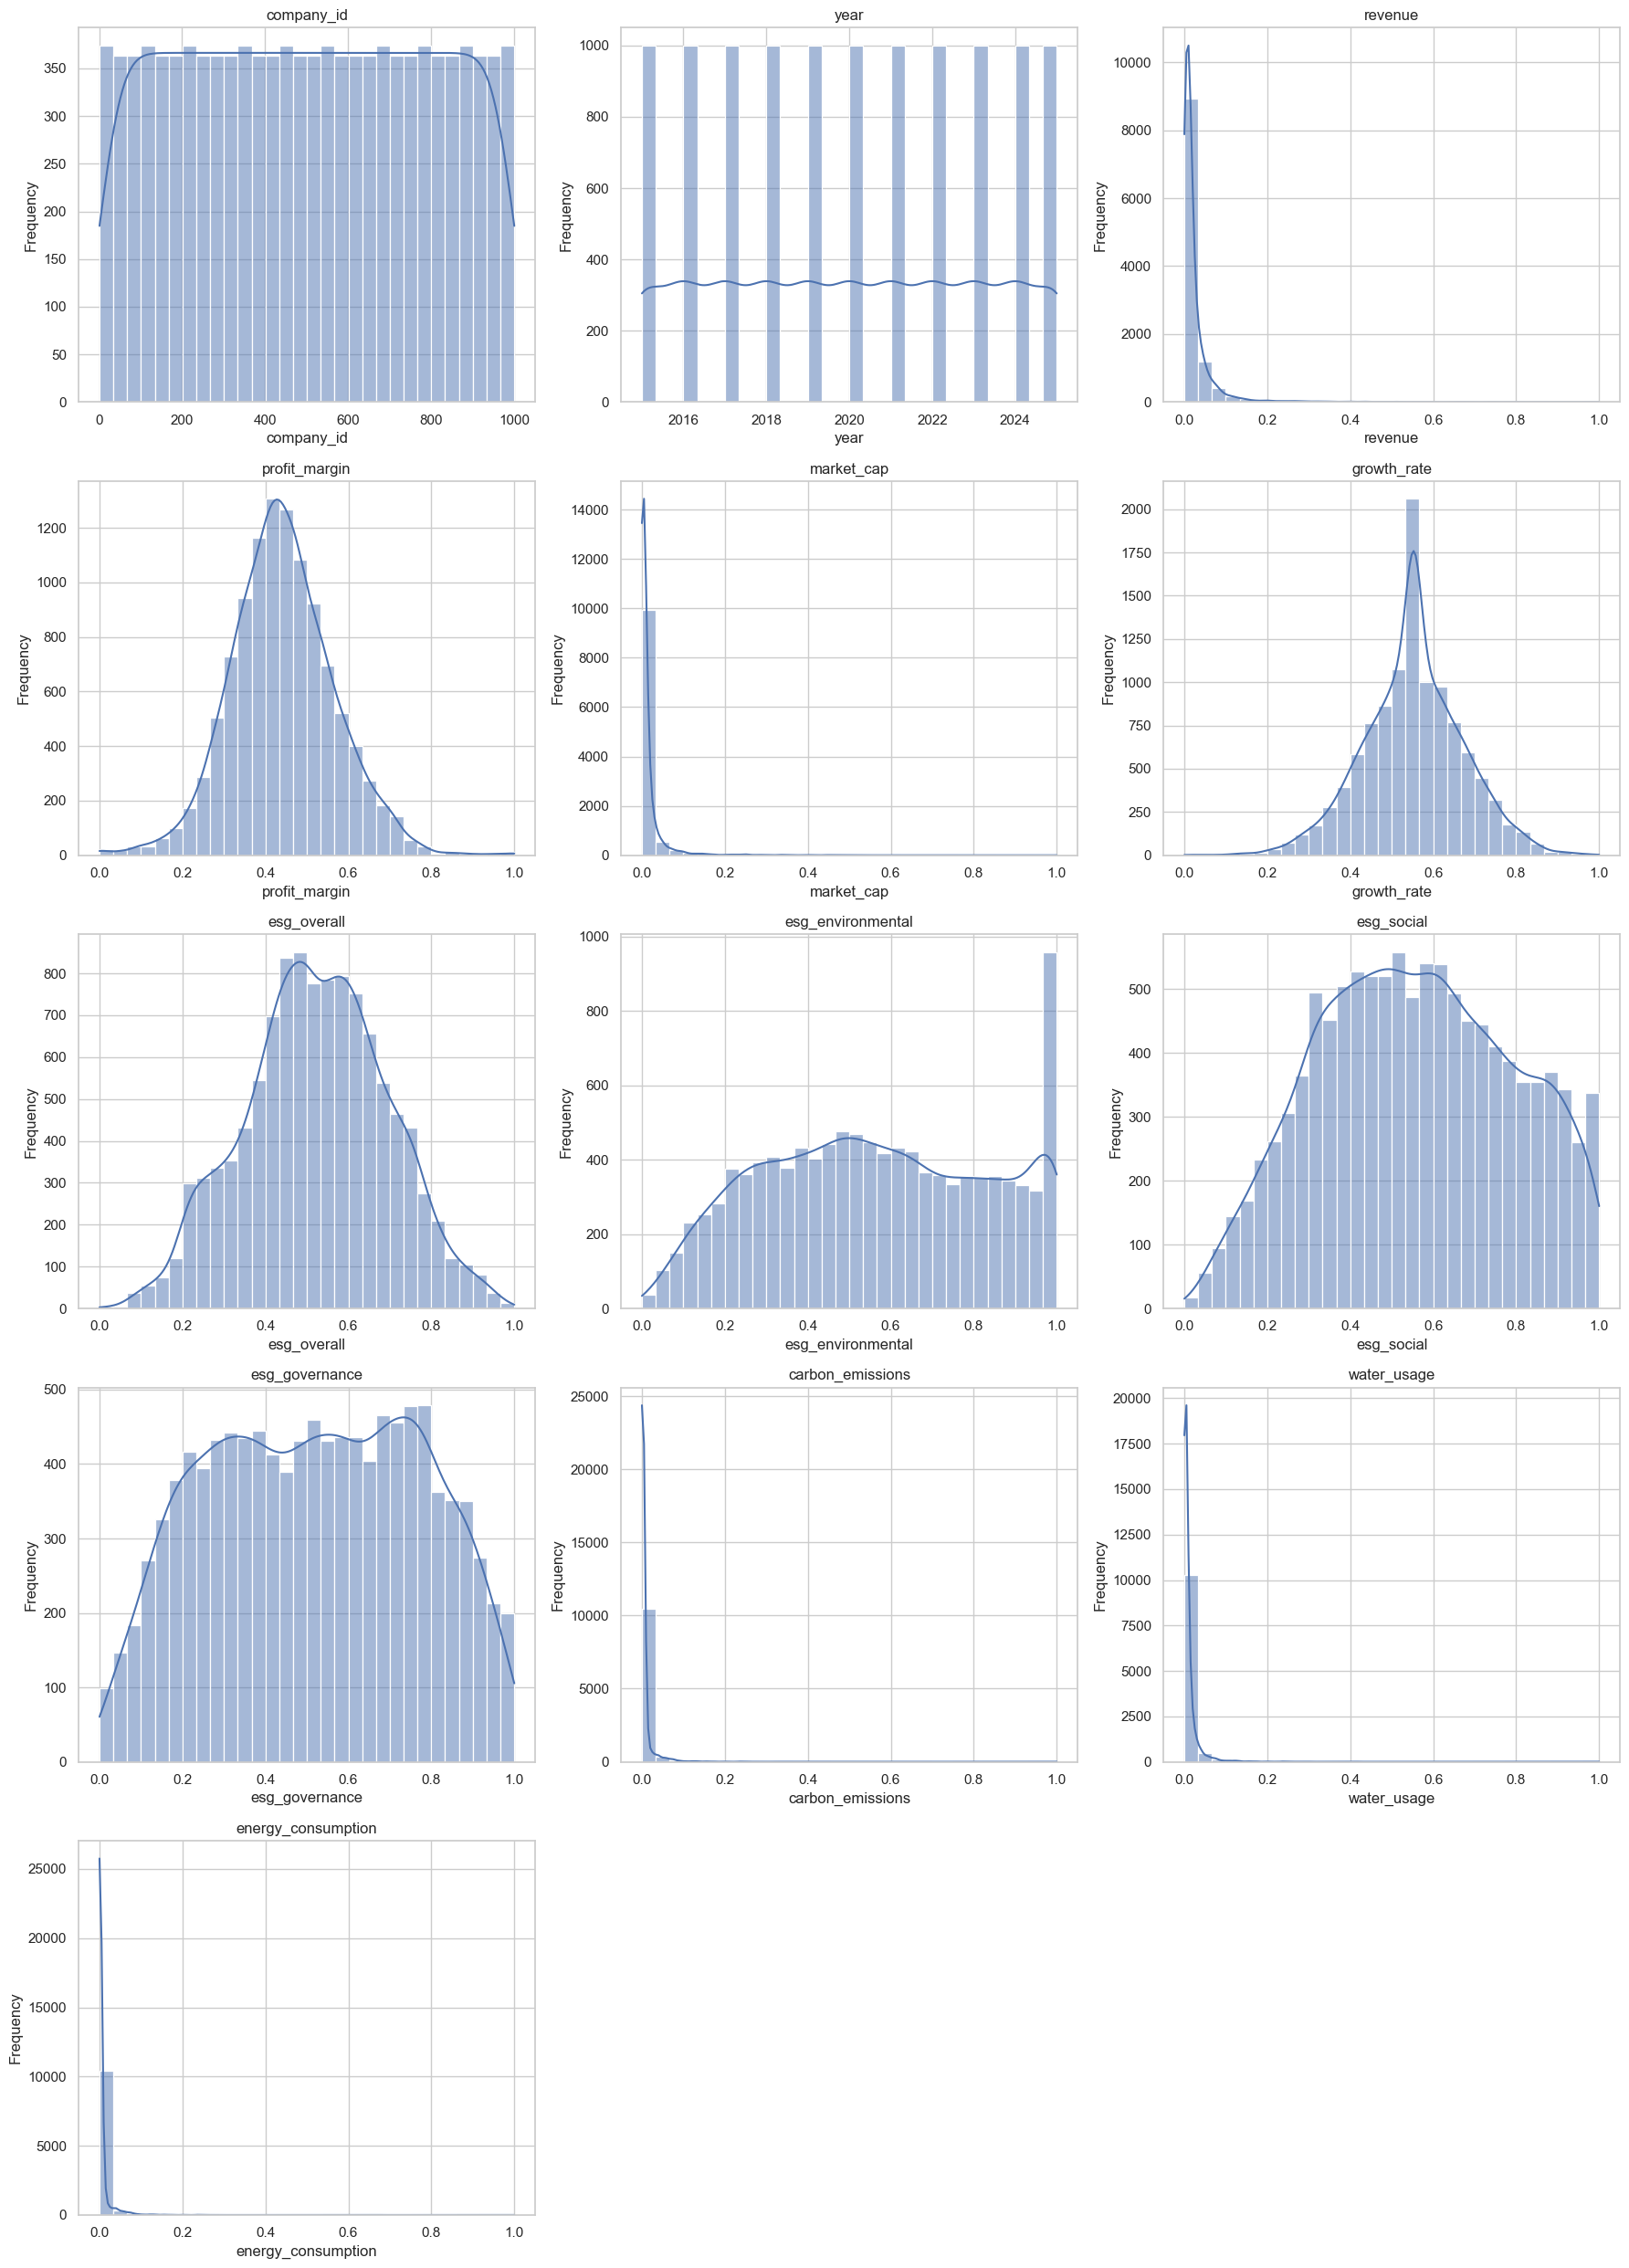

In [20]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [21]:
skewness = df[num_cols].skew().sort_values(ascending=False)
kurtosis = df[num_cols].kurtosis().sort_values(ascending=False)

dist_stats = pd.DataFrame({
    "Skewness": skewness,
    "Kurtosis": kurtosis
})

print("Distribution Metrics:")
display(dist_stats)

Distribution Metrics:


,Skewness,Kurtosis
carbon_emissions,15.850119,368.822009
company_id,0.000000,-1.200002
energy_consumption,15.655826,362.003262
esg_environmental,0.000174,-1.073793
esg_governance,-0.030436,-1.052276
esg_overall,-0.044713,-0.346144
esg_social,-0.000831,-0.858883
growth_rate,-0.082916,0.537249
market_cap,8.884838,111.402406
profit_margin,0.148783,0.808646


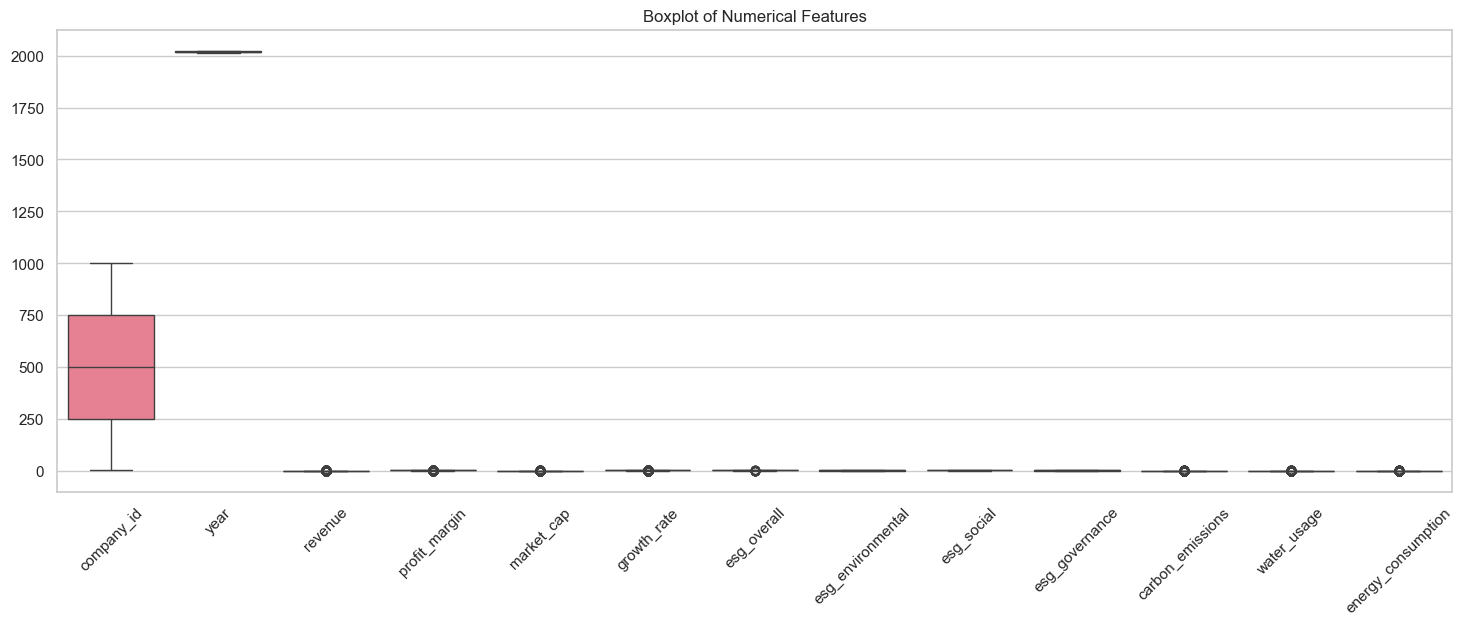

In [22]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

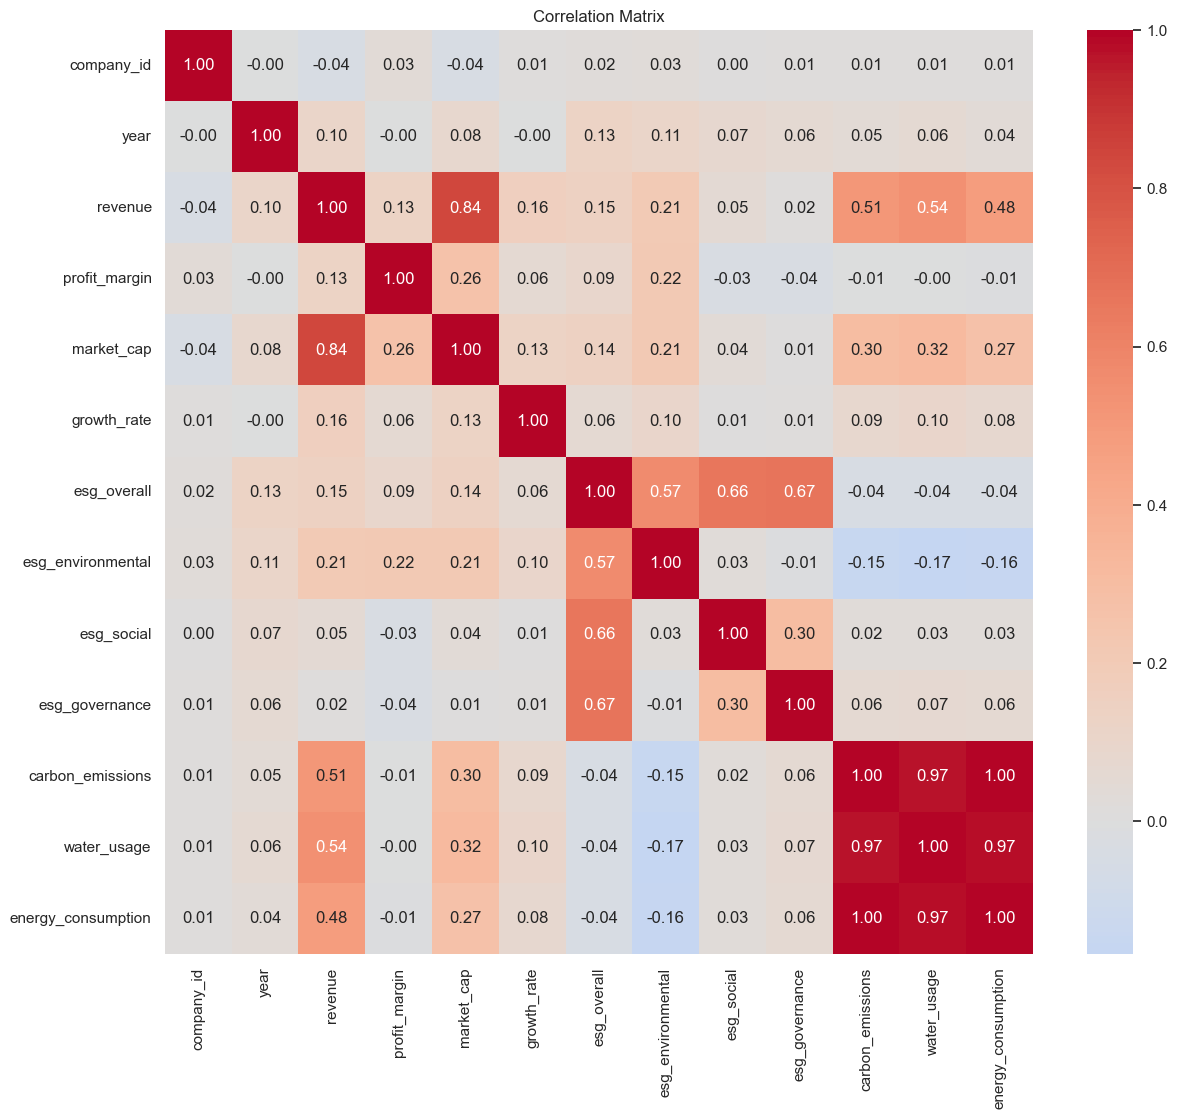

In [23]:
correlation = df[num_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

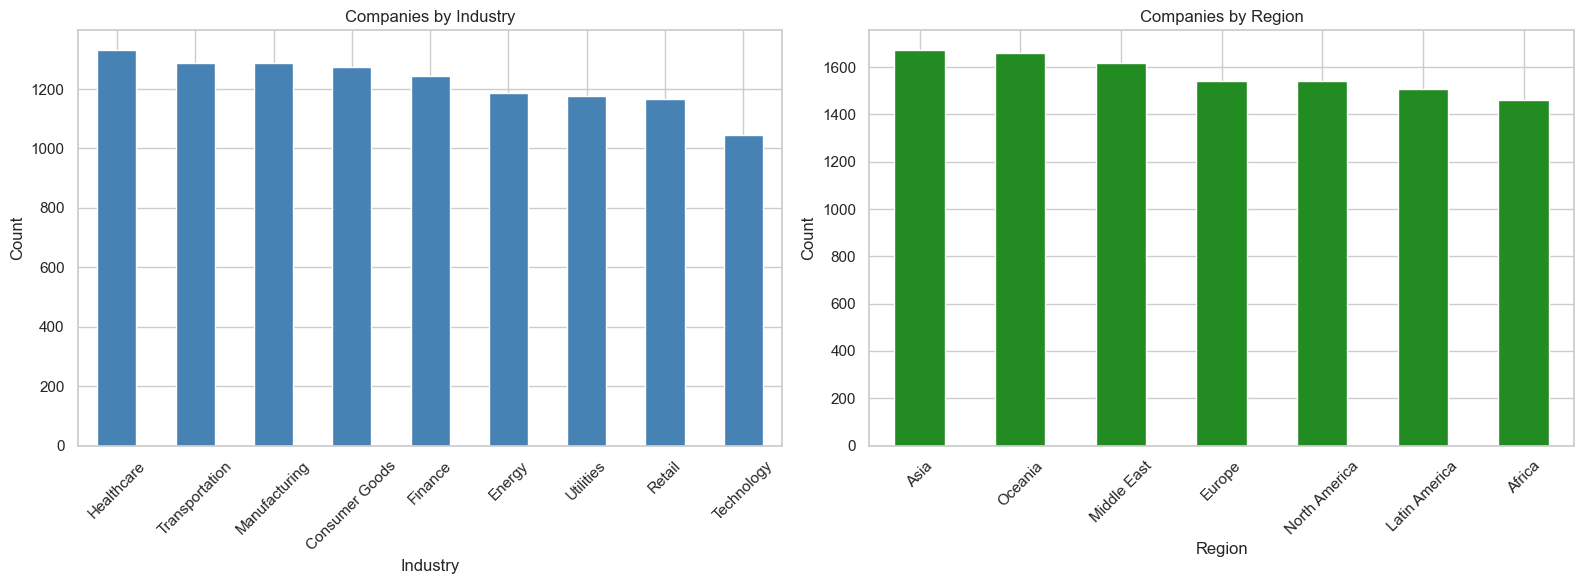

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df["industry"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Companies by Industry")
axes[0].set_xlabel("Industry")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

df["region"].value_counts().plot(kind="bar", ax=axes[1], color="forestgreen")
axes[1].set_title("Companies by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

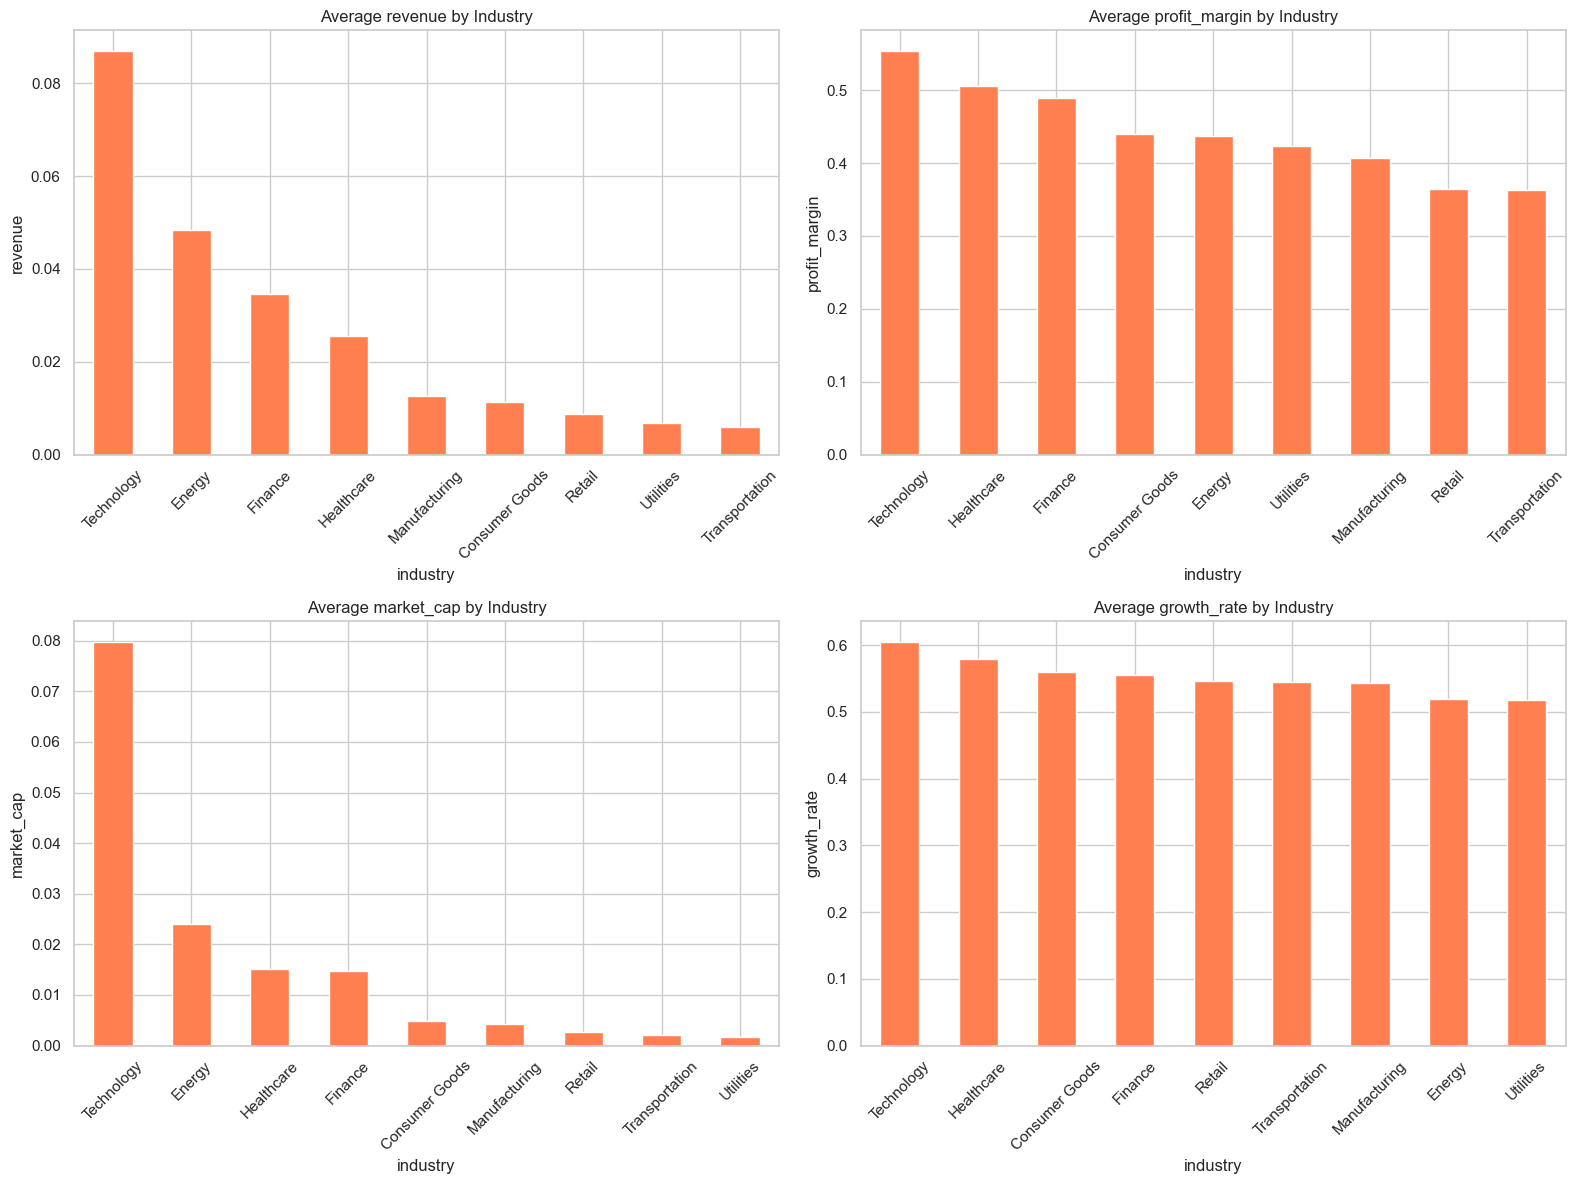

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ["revenue", "profit_margin", "market_cap", "growth_rate"]

for i, metric in enumerate(metrics):
    row, col = i // 2, i % 2
    df.groupby("industry")[metric].mean().sort_values(ascending=False).plot(
        kind="bar", ax=axes[row, col], color="coral"
    )
    axes[row, col].set_title(f"Average {metric} by Industry")
    axes[row, col].set_ylabel(metric)
    axes[row, col].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

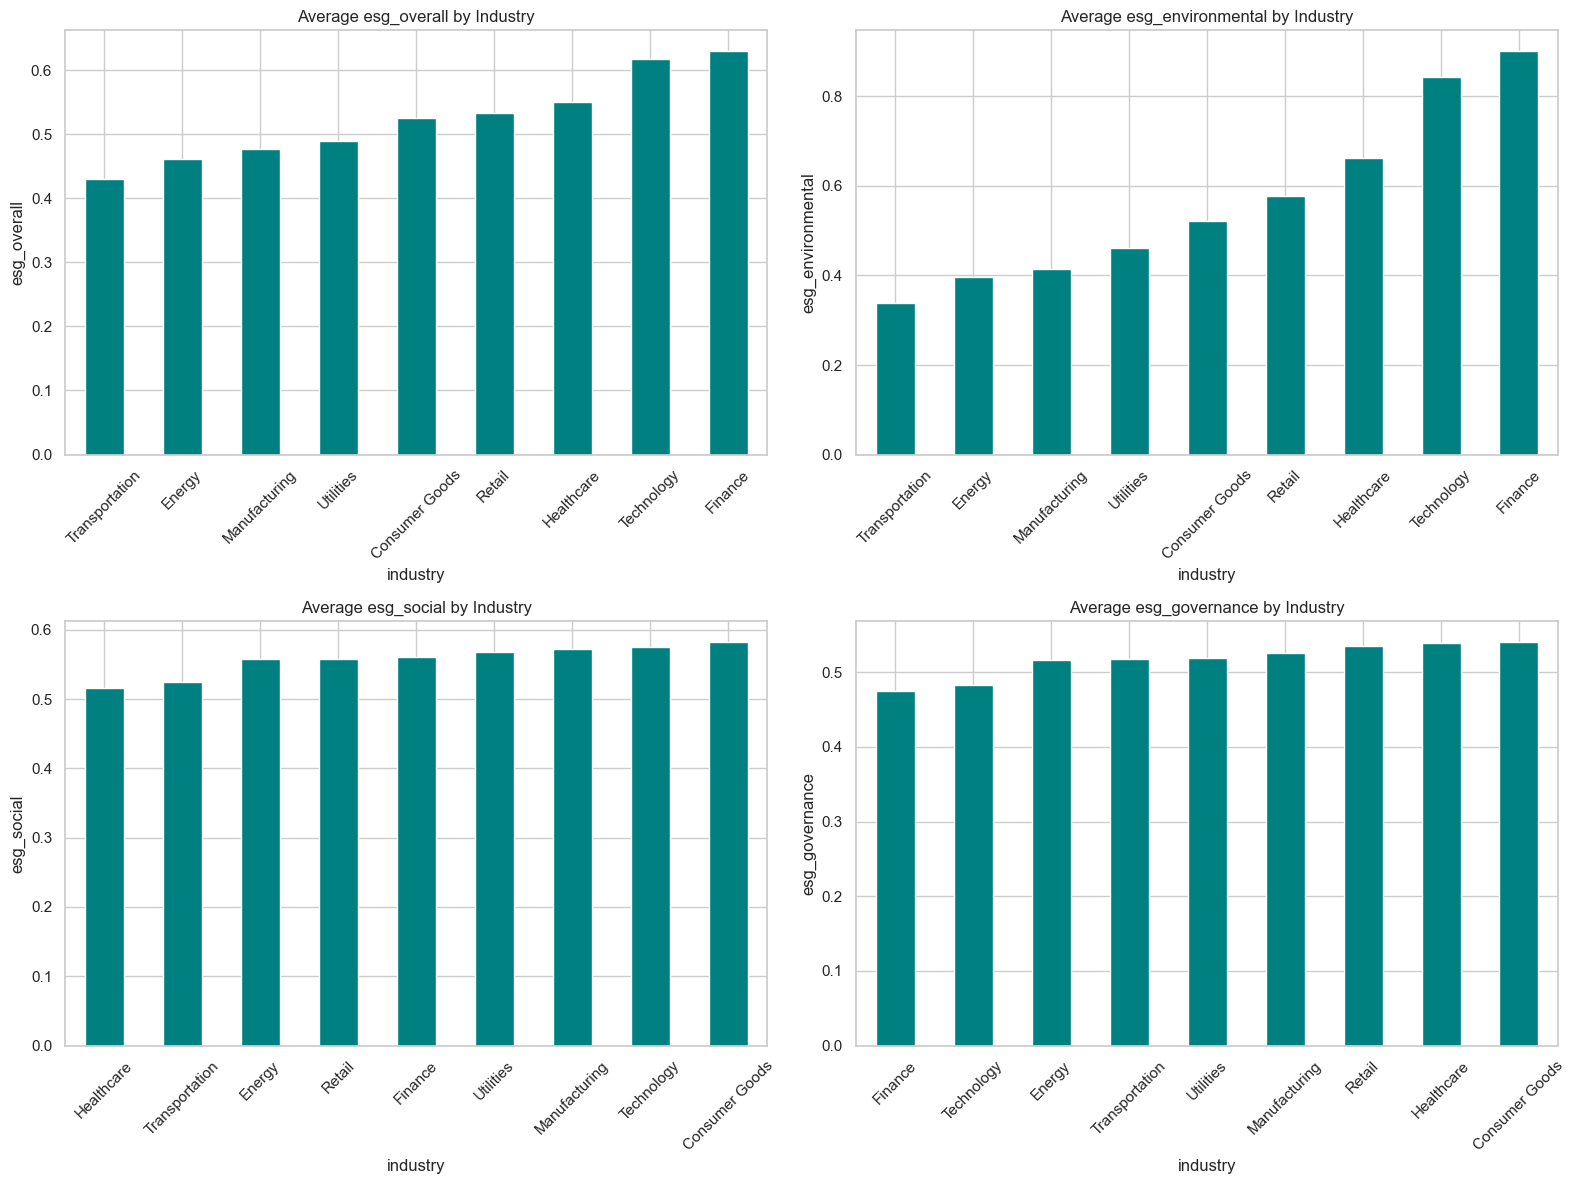

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

esg_cols = ["esg_overall", "esg_environmental", "esg_social", "esg_governance"]

for i, col in enumerate(esg_cols):
    row, col_idx = i // 2, i % 2
    df.groupby("industry")[col].mean().sort_values().plot(
        kind="bar", ax=axes[row, col_idx], color="teal"
    )
    axes[row, col_idx].set_title(f"Average {col} by Industry")
    axes[row, col_idx].set_ylabel(col)
    axes[row, col_idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

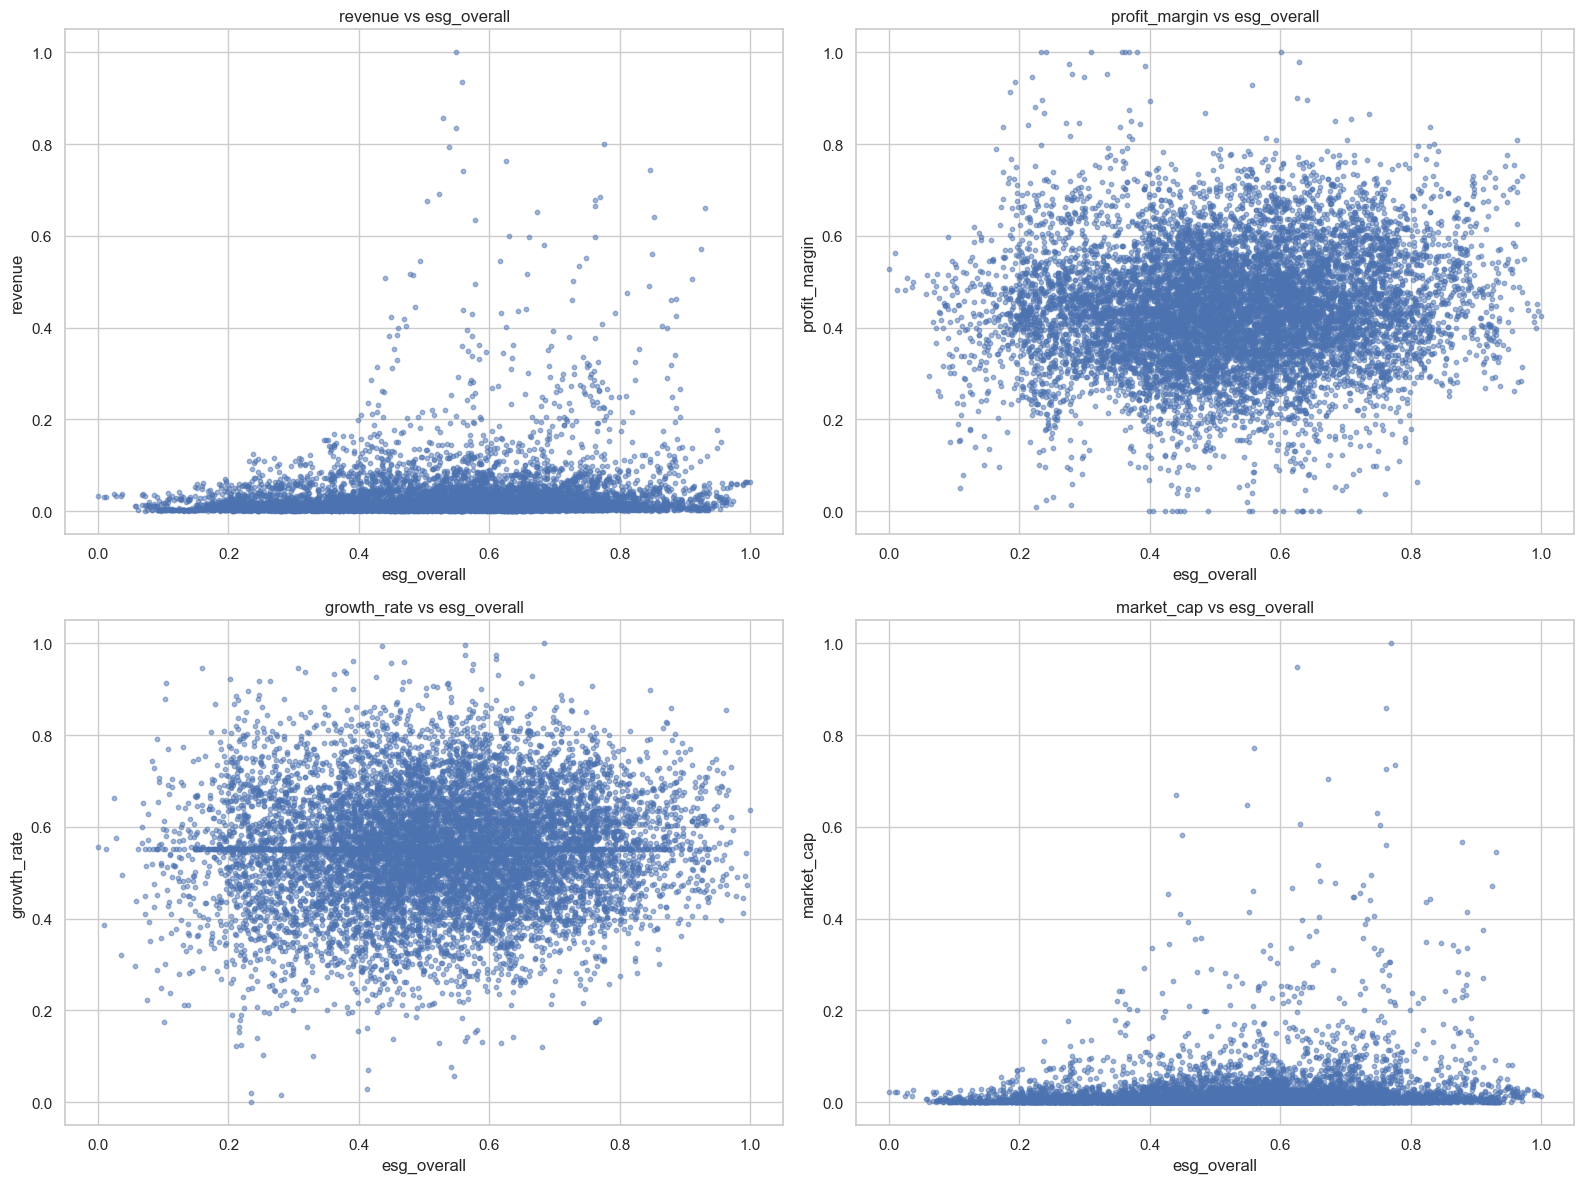

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

pairs = [
    ("esg_overall", "revenue"),
    ("esg_overall", "profit_margin"),
    ("esg_overall", "growth_rate"),
    ("esg_overall", "market_cap")
]

for i, (x, y) in enumerate(pairs):
    row, col_idx = i // 2, i % 2
    axes[row, col_idx].scatter(df[x], df[y], alpha=0.5, s=10)
    axes[row, col_idx].set_xlabel(x)
    axes[row, col_idx].set_ylabel(y)
    axes[row, col_idx].set_title(f"{y} vs {x}")

plt.tight_layout()
plt.show()

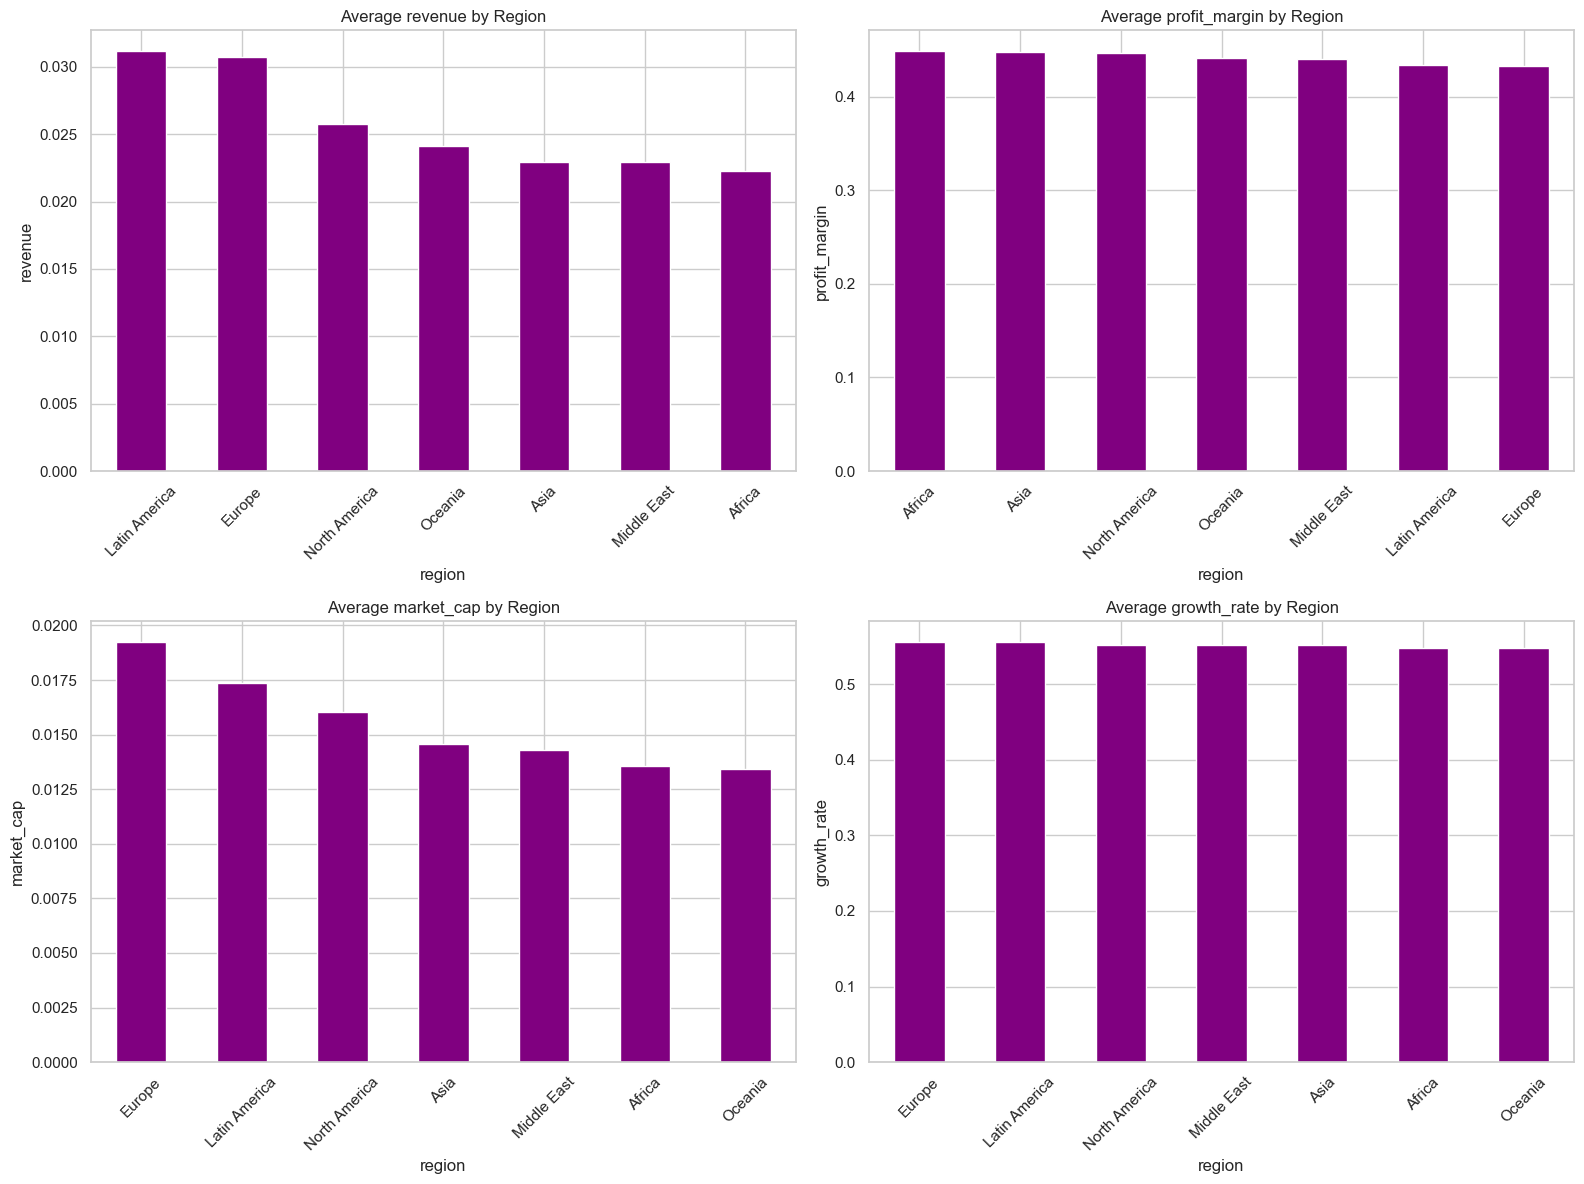

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, metric in enumerate(metrics):
    row, col_idx = i // 2, i % 2
    df.groupby("region")[metric].mean().sort_values(ascending=False).plot(
        kind="bar", ax=axes[row, col_idx], color="purple"
    )
    axes[row, col_idx].set_title(f"Average {metric} by Region")
    axes[row, col_idx].set_ylabel(metric)
    axes[row, col_idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

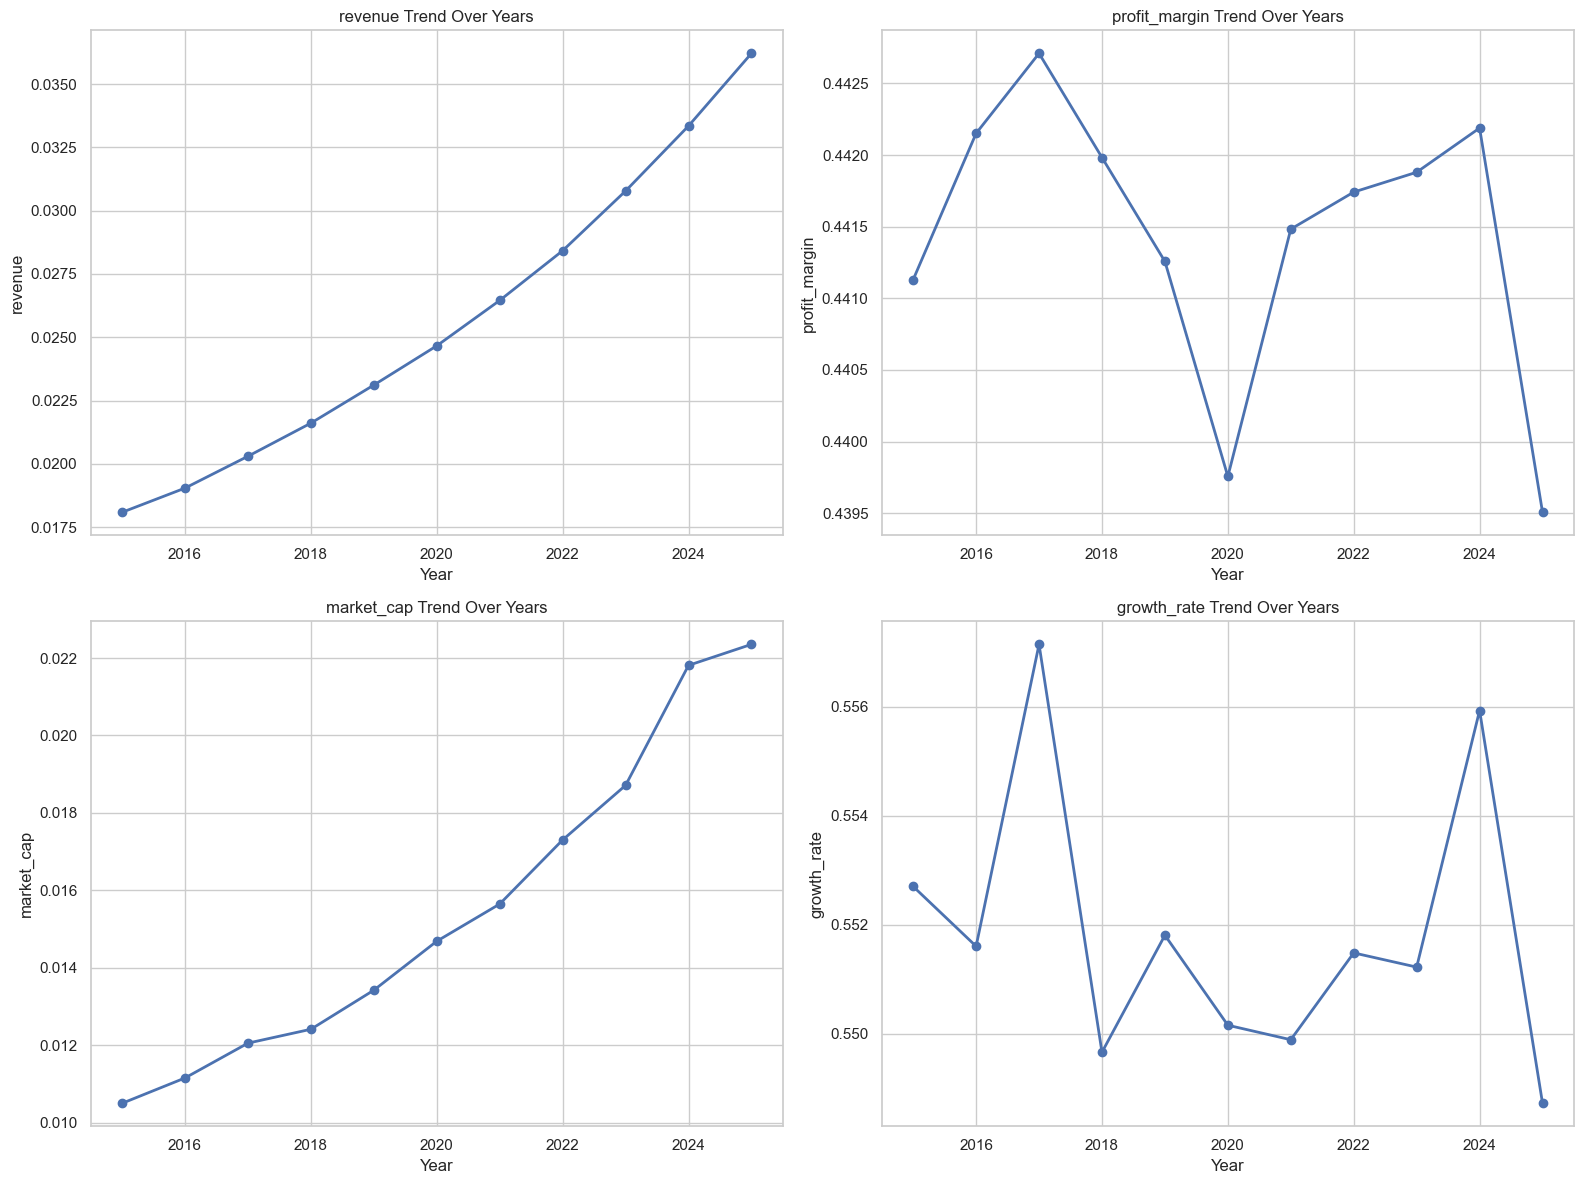

In [29]:
yearly_stats = df.groupby("year")[["revenue", "profit_margin", "market_cap", "growth_rate"]].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, metric in enumerate(["revenue", "profit_margin", "market_cap", "growth_rate"]):
    row, col_idx = i // 2, i % 2
    yearly_stats[metric].plot(ax=axes[row, col_idx], marker="o", linewidth=2)
    axes[row, col_idx].set_title(f"{metric} Trend Over Years")
    axes[row, col_idx].set_ylabel(metric)
    axes[row, col_idx].set_xlabel("Year")

plt.tight_layout()
plt.show()

In [30]:
print("Key Observations:")
print("-" * 40)
print(f"Total companies: {df['company_id'].nunique()}")
print(f"Industries: {', '.join(df['industry'].unique())}")
print(f"Regions: {', '.join(df['region'].unique())}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")
print()
print("Highest revenue industry:", df.groupby("industry")["revenue"].mean().idxmax())
print("Highest profit margin industry:", df.groupby("industry")["profit_margin"].mean().idxmax())
print("Highest ESG overall industry:", df.groupby("industry")["esg_overall"].mean().idxmax())
print()
print("Strongest correlation pairs:")
corr_pairs = correlation.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
display(corr_pairs.head(10))

Key Observations:
----------------------------------------
Total companies: 1000
Industries: Retail, Transportation, Technology, Finance, Healthcare, Energy, Consumer Goods, Utilities, Manufacturing
Regions: Latin America, Asia, Africa, Middle East, Oceania, Europe, North America
Year range: 2015 to 2025

Highest revenue industry: Technology
Highest profit margin industry: Technology
Highest ESG overall industry: Finance

Strongest correlation pairs:


energy_consumption  carbon_emissions      0.997210
carbon_emissions    energy_consumption    0.997210
energy_consumption  water_usage           0.974503
water_usage         energy_consumption    0.974503
                    carbon_emissions      0.968974
carbon_emissions    water_usage           0.968974
revenue             market_cap            0.836884
market_cap          revenue               0.836884
esg_governance      esg_overall           0.671476
esg_overall         esg_governance        0.671476
dtype: float64